# Phase 2 — Weather-Informed Workforce Allocation

---
## Section 0 — Research Framing

### 0.1 Research Question
How effectively can weather-sensitive demands improve workforce allocation 
efficiency? 

### 0.2 Hypotheses
- **H₀:** Workforce allocation decisions based on weather-sensitive demand forecasts do
  not significantly reduce workforce mismatches (overstaffing or understaffing) compared
  to traditional methods.
- **H₁:** Workforce allocation decisions based on weather-sensitive demand forecasts
  significantly reduce workforce mismatches (overstaffing or understaffing) compared to
  traditional methods.

### 0.3 LP Model Design

| Component | Decision |
|---|---|
| Decision variable | Number of employees per month (integer) |
| Objective | Minimise total workforce mismatch (overstaffed + understaffed employee-months) |
| Productivity ratio (λ) | **Empirically derived** from Statistics Canada tables 14-10-0203-01 and 14-10-0355-01 |
| Wage rate | Static average 2017–2025, Trade [41-45N] Ontario (Statistics Canada 14-10-0203-01) |
| Understaffing penalty | 2× overstaffing penalty — Mani et al. (2015) |
| Sectors | All 5 from Phase 1 |
| Statistical test | Wilcoxon signed-rank test on monthly mismatch differences |

### 0.4 Productivity Ratio (λ) — Empirical Derivation

Rather than relying on an external benchmark, λ is computed directly from
Statistics Canada data covering Ontario retail trade:

$$\lambda_t = \frac{N_t \times w_t \times 4.33}{S_t \times 1000}$$

where:
- $N_t$ = monthly employment in Trade [41-45N], Ontario (table 14-10-0355-01)
- $w_t$ = average weekly earnings excl. overtime, Trade [41-45N], Ontario (table 14-10-0203-01)
- $4.33$ = average weeks per month
- $S_t$ = Ontario retail sales ($000s) from sector data

The scalar λ used in the LP is the mean of $\lambda_t$ computed over a
**COVID-excluded** window (dropping March 2020 – June 2021) to avoid
structural distortions from temporary closures and government wage subsidies.

Since the **same** λ is applied to both SARIMA and SARIMAX LP runs, any
difference in workforce mismatch between the two models comes entirely from
differences in their forecast values — not from the productivity parameter.

### 0.5 Citations
- **Mani, V., Kesavan, S., & Swaminathan, J.M. (2015).** Estimating the impact of
  understaffing on sales and profitability in retail stores. *Production and Operations
  Management, 24*(2), 201–218. — Justifies 2× understaffing penalty multiplier.
- **Shah, B.J. (2021).** Determining optimal workforce size and schedule at the retail
  store considering overstaffing and understaffing costs. *European Journal of
  Operational Research.* — LP structure precedent.
- **Statistics Canada. (2025).** Table 14-10-0203-01: Average weekly earnings by
  industry, annual (x 1,000). — Monthly wage rate source.
- **Statistics Canada. (2025).** Table 14-10-0355-01: Employment by industry, monthly,
  seasonally unadjusted (x 1,000). — Monthly employment source for λ derivation.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import re
import warnings
from scipy.stats import wilcoxon
warnings.filterwarnings('ignore')

print('All libraries loaded ✓')

All libraries loaded ✓


---
## Section 1 — Load Phase 1 Outputs

Phase 1 fitted rolling SARIMA and SARIMAX models for all 5 sectors across 47
one-step-ahead evaluation windows and exported:

- `rolling_results` — per-sector dict with actuals, SARIMA forecasts, SARIMAX forecasts,
  MAPE values, and forecast errors for all 47 windows
- `analysis_df` — merged sales + weather dataframe (used for date alignment)
- `selected_sectors` — ordered list of 5 sector names
- `model_orders` — best SARIMA/SARIMAX orders per sector

No models are re-fitted in this notebook.

In [6]:
with open('../data/phase1_outputs.pkl', 'rb') as f:
    phase1 = pickle.load(f)

rolling_results  = phase1['rolling_results']
selected_sectors = phase1['selected_sectors']
analysis_df      = phase1['analysis_df']
model_orders     = phase1['model_orders']

MIN_TRAIN = 60  # matches Phase 1

print('Phase 1 outputs loaded:')
print(f'  Sectors           : {len(selected_sectors)}')
print(f'  Evaluation windows: {rolling_results[selected_sectors[0]]["n_evals"]} per sector')
print(f'  analysis_df shape : {analysis_df.shape}')
print(f'  Date range        : {analysis_df["YearMonth"].min()} → {analysis_df["YearMonth"].max()}')
print()
print('Phase 1 forecast accuracy recap:')
print(f'  {"Sector":<60} {"SARIMA MAPE":>12} {"SARIMAX MAPE":>13} {"ΔMAPE":>8}')
print('-' * 88)
for s in selected_sectors:
    r = rolling_results[s]
    delta = r['SARIMA_MAPE'] - r['SARIMAX_MAPE']
    sig   = ' ← significant (DM p=0.042)' if '4412' in s else ''
    print(f'  {s:<60} {r["SARIMA_MAPE"]:>11.2f}% {r["SARIMAX_MAPE"]:>12.2f}% {delta:>+7.2f}pp{sig}')

Phase 1 outputs loaded:
  Sectors           : 5
  Evaluation windows: 47 per sector
  analysis_df shape : (107, 34)
  Date range        : 2017-01-01 00:00:00 → 2025-11-01 00:00:00

Phase 1 forecast accuracy recap:
  Sector                                                        SARIMA MAPE  SARIMAX MAPE    ΔMAPE
----------------------------------------------------------------------------------------
  Other motor vehicle dealers [4412]                                 19.53%        17.78%   +1.75pp ← significant (DM p=0.042)
  Convenience retailers and vending machine operators [44513]         3.62%         4.32%   -0.70pp
  Miscellaneous retailers [459B]                                      5.46%         5.48%   -0.02pp
  Electronics and appliances retailers [4492]                         4.69%         4.81%   -0.12pp
  New car dealers [44111]                                             6.82%         7.22%   -0.39pp


---
## Section 2 — Labour Market Data & Empirical λ Derivation

### 2.1 Data Sources

| Table | Content | Role |
|---|---|---|
| `14-10-0355-01` | Monthly employment, Wholesale & retail trade [41-45N], Ontario, unadjusted | Monthly headcount $N_t$ for λ derivation |
| `14-10-0203-01` | Monthly avg weekly earnings, Trade [41-45N], Ontario, excl. overtime | Monthly wage rate $w_t$ for λ derivation and LP cost parameters |

### 2.2 Parsing Helpers

In [7]:
def parse_statcan_wide(filepath, target_keyword):
    """Parse a Statistics Canada wide-format CSV (symbolsSeparate format)."""
    with open(filepath, 'r', encoding='utf-8-sig') as f:
        lines = f.readlines()

    header_idx = next(i for i, l in enumerate(lines) if 'January 2017' in l)
    cols_raw   = lines[header_idx].strip().split('","')
    cols       = [c.strip('"') for c in cols_raw]
    val_cols   = [c for c in cols if re.match(r'[A-Z][a-z]+ \d{4}$', c)]

    data = []
    for line in lines[header_idx + 2:]:
        stripped = line.strip()
        if not stripped: break
        parts = [c.strip('"') for c in stripped.split('","')]
        if len(parts) >= 3 and parts[0] and not parts[0][0].isdigit():
            data.append(parts)

    df         = pd.DataFrame(data)
    df.columns = cols[:df.shape[1]]
    naics_col  = df.columns[0]
    target_row = df[df[naics_col].str.contains(target_keyword, regex=False, na=False)]
    if target_row.empty:
        raise ValueError(f'Keyword "{target_keyword}" not found.')

    result = {}
    for c in val_cols:
        if c in df.columns:
            try:   result[c] = float(target_row.iloc[0][c].replace(',', '').strip())
            except ValueError: result[c] = np.nan

    series       = pd.Series(result)
    series.index = pd.to_datetime(series.index, format='%B %Y')
    return series.sort_index()

print('parse_statcan_wide() defined.')

parse_statcan_wide() defined.


### 2.3 Load Earnings and Employment Series

In [8]:
START = pd.Timestamp('2017-01-01')
END   = pd.Timestamp('2025-11-01')

# Average weekly earnings (14-10-0203-01) — used for wage rate and λ
earnings = parse_statcan_wide(
    '../data/average_weekly_earnings.csv', 'Trade'
).loc[START:END]

# Monthly employment (14-10-0355-01) — used for λ derivation only
# Units: thousands of persons (multiply by 1000 to get headcount)
employment = parse_statcan_wide(
    '../data/monthly_employment.csv', 'Wholesale and retail trade'
).loc[START:END]

WEEKS_PER_MONTH = 4.33

print('Earnings series:')
print(f'  Range  : {earnings.index[0].strftime("%b %Y")} → {earnings.index[-1].strftime("%b %Y")}')
print(f'  Months : {len(earnings)}  |  Missing: {earnings.isna().sum()}')
print(f'  Mean   : ${earnings.mean():,.2f}/week')
print()
print('Employment series:')
print(f'  Range  : {employment.index[0].strftime("%b %Y")} → {employment.index[-1].strftime("%b %Y")}')
print(f'  Months : {len(employment)}  |  Missing: {employment.isna().sum()}')
print(f'  Mean   : {employment.mean():,.1f}k persons  ({employment.mean()*1000:,.0f} employees)')

Earnings series:
  Range  : Jan 2017 → Nov 2025
  Months : 107  |  Missing: 0
  Mean   : $890.88/week

Employment series:
  Range  : Jan 2017 → Nov 2025
  Months : 107  |  Missing: 0
  Mean   : 1,116.4k persons  (1,116,372 employees)


### 2.4 Empirical λ Derivation

The labour-cost-to-sales ratio λ is computed monthly as:

$$\lambda_t = \frac{N_t \times w_t \times 4.33}{S_t^{\text{all}}}$$

where:
- $N_t$ = monthly employment in Trade [41-45N], Ontario, in thousands of persons (table 14-10-0355-01)
- $w_t$ = average weekly earnings excl. overtime, Trade [41-45N], Ontario, in $/week (table 14-10-0203-01)
- $4.33$ = average weeks per month
- $S_t^{\text{all}}$ = aggregate Ontario retail sales across **all 28 sub-sectors** in $000s

**Why all 28 sectors?** Employment table 14-10-0355-01 covers all of Trade [41-45N] —
it cannot be disaggregated to individual NAICS sub-sectors. Using only the 5 selected
sectors' sales as the denominator would severely undercount revenue relative to the
workforce, inflating λ to implausible levels (~60%). Summing all 28 available sub-sector
sales columns aligns the denominator scope with the numerator, producing a λ that
reflects the true labour intensity of Ontario retail trade.

The scalar λ used in the LP is the mean of $\lambda_t$ computed over a
**COVID-excluded** window (dropping March 2020 – June 2021) to avoid
structural distortions from temporary closures and government wage subsidies
(CEWS, CERB).

Since the **same** λ is applied to both SARIMA and SARIMAX LP runs, any
difference in workforce mismatch between the two models comes entirely from
differences in their forecast values — not from the productivity parameter.


In [9]:
# Aggregate sales across ALL 28 retail sectors to match the scope of
# employment table 14-10-0355-01, which covers all of Trade [41-45N]
# Using only the 5 selected sectors would undercount the sales denominator
# and inflate λ to implausible levels (~60%+)
sector_cols_all = [c for c in analysis_df.columns
                   if c not in ['YearMonth', 'HDD_18', 'CDD_18',
                               'PRECTOTCORR', 'ALLSKY_SFC_SW_DWN', 'Snow_Day']]
sales_agg = (
    analysis_df
    .set_index('YearMonth')[sector_cols_all]
    .sum(axis=1)
    .rename('total_sales')
)

# Align all three series to a common monthly index
lambda_df = pd.DataFrame({
    'earnings':   earnings,
    'employment': employment,   # units: thousands of persons
    'sales':      sales_agg,    # units: $000s
}).dropna()

# Wage bill = employment(000s) × earnings($/wk) × 4.33 wks
# Units: (thousands of persons) × ($/person/wk) × wks = thousands of $
# Sales units: $000s = thousands of $
# λ = (thousands of $) / (thousands of $) → dimensionless ✓
lambda_df['wage_bill'] = lambda_df['employment'] * lambda_df['earnings'] * WEEKS_PER_MONTH
lambda_df['lambda_t']  = lambda_df['wage_bill'] / lambda_df['sales']

# COVID exclusion mask
COVID_START = pd.Timestamp('2020-03-01')
COVID_END   = pd.Timestamp('2021-06-01')
pre_covid_mask  = lambda_df.index < COVID_START
post_covid_mask = lambda_df.index > COVID_END
non_covid_mask  = pre_covid_mask | post_covid_mask

lambda_full    = lambda_df['lambda_t'].mean()
LABOUR_SHARE   = lambda_df.loc[non_covid_mask, 'lambda_t'].mean()   # ← used in LP
lambda_covid   = lambda_df.loc[~non_covid_mask, 'lambda_t'].mean()

print('Empirical λ derivation results:')
print(f'  Full series mean (incl. COVID) : {lambda_full:.4f}  ({lambda_full*100:.2f}%)')
print(f'  COVID-period mean only         : {lambda_covid:.4f}  ({lambda_covid*100:.2f}%)')
print(f'  COVID-excluded mean            : {LABOUR_SHARE:.4f}  ({LABOUR_SHARE*100:.2f}%)')
print()
print(f'  → LABOUR_SHARE (λ) used in LP  : {LABOUR_SHARE:.4f}  ({LABOUR_SHARE*100:.2f}%)')
print()
print(f'  All-sector sales columns used  : {len(sector_cols_all)}')
print(f'  Non-COVID months used          : {non_covid_mask.sum()} of {len(lambda_df)}')
print(f'  λ range (non-COVID)            : [{lambda_df.loc[non_covid_mask, "lambda_t"].min():.4f}, '
      f'{lambda_df.loc[non_covid_mask, "lambda_t"].max():.4f}]')
print(f'  λ std dev (non-COVID)          : {lambda_df.loc[non_covid_mask, "lambda_t"].std():.4f}')


Empirical λ derivation results:
  Full series mean (incl. COVID) : 0.0947  (9.47%)
  COVID-period mean only         : 0.0956  (9.56%)
  COVID-excluded mean            : 0.0945  (9.45%)

  → LABOUR_SHARE (λ) used in LP  : 0.0945  (9.45%)

  All-sector sales columns used  : 30
  Non-COVID months used          : 91 of 107
  λ range (non-COVID)            : [0.0809, 0.1217]
  λ std dev (non-COVID)          : 0.0092


### 2.5 Visualise λ Over Time

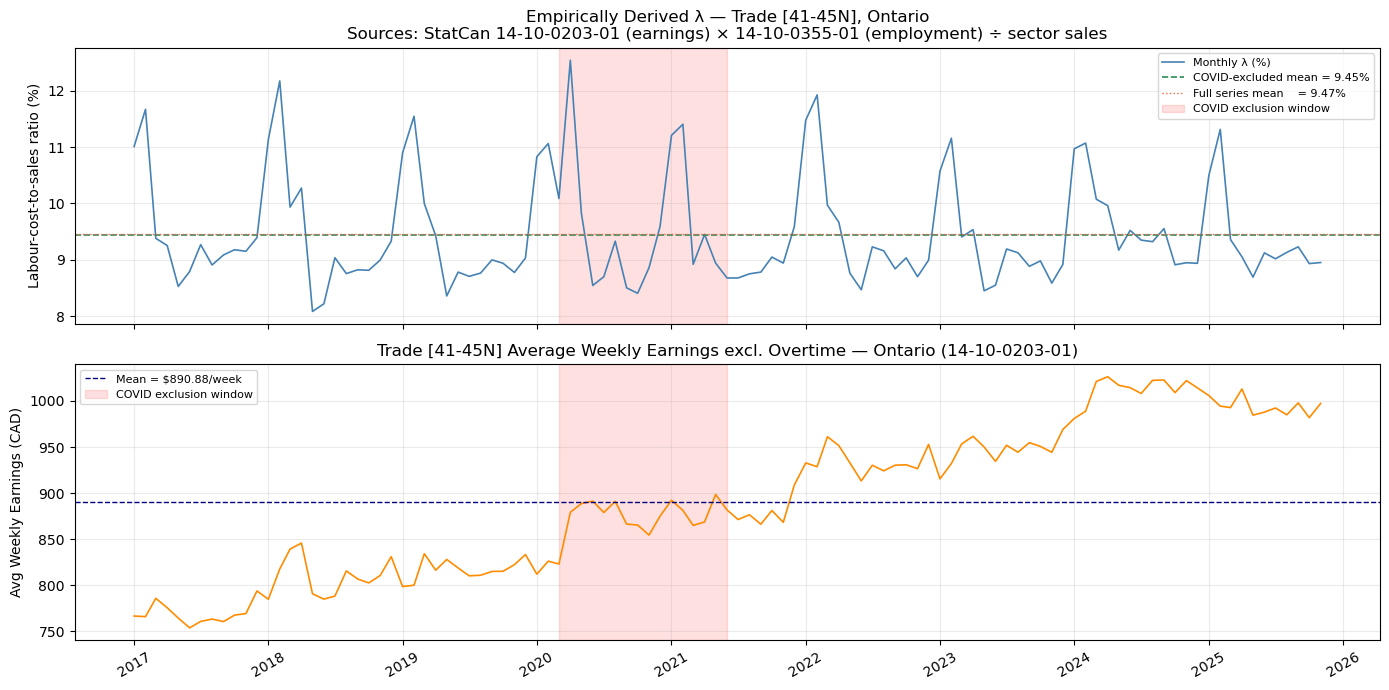

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top: monthly λ
ax = axes[0]
ax.plot(lambda_df.index, lambda_df['lambda_t'] * 100,
        color='steelblue', lw=1.2, label='Monthly λ (%)')
ax.axhline(LABOUR_SHARE * 100, color='seagreen', lw=1.2, ls='--',
           label=f'COVID-excluded mean = {LABOUR_SHARE*100:.2f}%')
ax.axhline(lambda_full  * 100, color='tomato',   lw=1.0, ls=':',
           label=f'Full series mean    = {lambda_full*100:.2f}%')
ax.axvspan(COVID_START, COVID_END, alpha=0.12, color='red', label='COVID exclusion window')
ax.set_ylabel('Labour-cost-to-sales ratio (%)')
ax.set_title('Empirically Derived λ — Trade [41-45N], Ontario\n'
             'Sources: StatCan 14-10-0203-01 (earnings) × 14-10-0355-01 (employment) ÷ sector sales')
ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

# Bottom: earnings series for context
ax2 = axes[1]
ax2.plot(earnings.index, earnings.values, color='darkorange', lw=1.2)
ax2.axhline(earnings.mean(), color='navy', lw=1, ls='--',
            label=f'Mean = ${earnings.mean():,.2f}/week')
ax2.axvspan(COVID_START, COVID_END, alpha=0.12, color='red', label='COVID exclusion window')
ax2.set_ylabel('Avg Weekly Earnings (CAD)')
ax2.set_title('Trade [41-45N] Average Weekly Earnings excl. Overtime — Ontario (14-10-0203-01)')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.25)
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 2.6 LP Cost Parameters

In [11]:
UNDERSTAFF_MULT = 2.0    # Mani et al. (2015)

monthly_wage = earnings.mean() * WEEKS_PER_MONTH
cost_over    = monthly_wage
cost_under   = monthly_wage * UNDERSTAFF_MULT

print('LP parameters (all derived from Statistics Canada data):')
print(f'  Labour share λ (empirical, COVID-excluded) : {LABOUR_SHARE:.4f}  ({LABOUR_SHARE*100:.2f}%)')
print(f'  Monthly wage (static avg, 14-10-0203-01)   : ${monthly_wage:,.2f} per employee')
print(f'  Overstaffing cost                          : ${cost_over:,.2f} per employee-month')
print(f'  Understaffing cost (2× — Mani et al. 2015) : ${cost_under:,.2f} per employee-month')

LP parameters (all derived from Statistics Canada data):
  Labour share λ (empirical, COVID-excluded) : 0.0945  (9.45%)
  Monthly wage (static avg, 14-10-0203-01)   : $3,857.52 per employee
  Overstaffing cost                          : $3,857.52 per employee-month
  Understaffing cost (2× — Mani et al. 2015) : $7,715.04 per employee-month


---
## Section 3 — LP Model

### 3.1 Formulation

For each evaluation window $t$ and sector $s$, a manager makes a staffing decision
based on the demand forecast available at the start of the month. The LP determines
the allocation that minimises expected mismatch cost.

**Staffing decision (based on forecast):**

$$e_t = \text{round}\left(\frac{\text{Forecast}_t \times 1000 \times \lambda}{w}\right)$$

where $\lambda$ is the empirically derived labour share and $w$ is monthly wage.

**Required employees (revealed when actual demand is known):**

$$r_t = \text{round}\left(\frac{\text{Actual}_t \times 1000 \times \lambda}{w}\right)$$

**Workforce mismatch:**

$$s_t^+ = \max(0,\ e_t - r_t) \quad \text{(overstaffing)}$$

$$s_t^- = \max(0,\ r_t - e_t) \quad \text{(understaffing)}$$

**Penalty cost:**

$$C_t = c_{over} \cdot s_t^+ + c_{under} \cdot s_t^-$$

where $c_{over} = w$ and $c_{under} = 2w$ (Mani et al., 2015).

**The LP is run twice per window** — once with the SARIMA forecast and once with the
SARIMAX forecast. All parameters are identical across both runs.

### 3.2 Why Integer Rounding Matters

Rounding $e_t$ and $r_t$ to whole employees introduces a non-linear step that
decouples the Phase 2 results from a simple linear rescaling of Phase 1 forecast
errors. Two forecasts with similar MAPE values can produce different mismatch outcomes
depending on which side of an integer boundary they fall. This makes Phase 2 a
genuinely independent analysis rather than a direct transformation of Phase 1 numbers.

In [12]:
def compute_lp(forecast, actual, labour_share, monthly_wage, cost_over, cost_under):
    """
    Compute workforce allocation and mismatch for a single evaluation window.

    Parameters
    ----------
    forecast      : float — one-step-ahead sales forecast ($000)
    actual        : float — realised sales ($000)
    labour_share  : float — empirically derived labour cost share of revenue
    monthly_wage  : float — static monthly wage per employee ($)
    cost_over     : float — cost per overstaffed employee-month ($)
    cost_under    : float — cost per understaffed employee-month ($)

    Returns
    -------
    dict with: allocated, required, overstaff, understaff, penalty_cost
    """
    allocated  = round((forecast * 1_000 * labour_share) / monthly_wage)
    required   = round((actual   * 1_000 * labour_share) / monthly_wage)
    overstaff  = max(0, allocated - required)
    understaff = max(0, required  - allocated)
    penalty    = overstaff * cost_over + understaff * cost_under

    return {
        'allocated':    allocated,
        'required':     required,
        'overstaff':    overstaff,
        'understaff':   understaff,
        'penalty_cost': round(penalty, 2),
    }

print('compute_lp() defined.')
print()
print('Sanity checks:')
t1 = compute_lp(600_000, 500_000, LABOUR_SHARE, monthly_wage, cost_over, cost_under)
t2 = compute_lp(500_000, 600_000, LABOUR_SHARE, monthly_wage, cost_over, cost_under)
t3 = compute_lp(500_000, 500_000, LABOUR_SHARE, monthly_wage, cost_over, cost_under)
print(f'  Overstaff  case — forecast=$600k, actual=$500k')
print(f'    Allocated={t1["allocated"]:,}  Required={t1["required"]:,}  '
      f'Overstaff={t1["overstaff"]:,} emp  Penalty=${t1["penalty_cost"]:,.2f}')
print(f'  Understaff case — forecast=$500k, actual=$600k')
print(f'    Allocated={t2["allocated"]:,}  Required={t2["required"]:,}  '
      f'Understaff={t2["understaff"]:,} emp  Penalty=${t2["penalty_cost"]:,.2f}')
print(f'  Perfect    case — forecast=$500k, actual=$500k')
print(f'    Allocated={t3["allocated"]:,}  Required={t3["required"]:,}  '
      f'Penalty=${t3["penalty_cost"]:,.2f}')
print()
if t1['overstaff'] > 0 and t2['understaff'] > 0:
    ratio = t2['penalty_cost'] / t1['penalty_cost']
    print(f'  Understaff penalty is {ratio:.1f}× overstaff penalty ✓  (Mani et al. 2× multiplier)')

compute_lp() defined.

Sanity checks:
  Overstaff  case — forecast=$600k, actual=$500k
    Allocated=14,696  Required=12,247  Overstaff=2,449 emp  Penalty=$9,447,065.76
  Understaff case — forecast=$500k, actual=$600k
    Allocated=12,247  Required=14,696  Understaff=2,449 emp  Penalty=$18,894,131.53
  Perfect    case — forecast=$500k, actual=$500k
    Allocated=12,247  Required=12,247  Penalty=$0.00

  Understaff penalty is 2.0× overstaff penalty ✓  (Mani et al. 2× multiplier)


---
## Section 4 — Run LP for All Sectors and Evaluation Windows

In [13]:
lp_results = {}

for sector in selected_sectors:
    r = rolling_results[sector]

    costs_s,  costs_sx    = [], []
    over_s,   over_sx     = [], []
    under_s,  under_sx    = [], []
    details_s, details_sx = [], []

    for t in range(r['n_evals']):
        fc_s  = r['forecasts_s'][t]
        fc_sx = r['forecasts_sx'][t]
        act   = r['actuals'][t]

        res_s  = compute_lp(fc_s,  act, LABOUR_SHARE, monthly_wage, cost_over, cost_under)
        res_sx = compute_lp(fc_sx, act, LABOUR_SHARE, monthly_wage, cost_over, cost_under)

        costs_s.append(res_s['penalty_cost']);  costs_sx.append(res_sx['penalty_cost'])
        over_s.append(res_s['overstaff']);      over_sx.append(res_sx['overstaff'])
        under_s.append(res_s['understaff']);    under_sx.append(res_sx['understaff'])
        details_s.append(res_s);               details_sx.append(res_sx)

    costs_s   = np.array(costs_s);   costs_sx  = np.array(costs_sx)
    over_s    = np.array(over_s);    over_sx   = np.array(over_sx)
    under_s   = np.array(under_s);   under_sx  = np.array(under_sx)

    mismatch_s    = over_s  + under_s
    mismatch_sx   = over_sx + under_sx
    mismatch_diff = mismatch_s - mismatch_sx

    total_s  = costs_s.sum();  total_sx = costs_sx.sum()
    saving   = total_s - total_sx
    pct      = (saving / total_s * 100) if total_s > 0 else 0.0

    lp_results[sector] = {
        'costs_sarima':     costs_s,
        'costs_sarimax':    costs_sx,
        'total_sarima':     total_s,
        'total_sarimax':    total_sx,
        'dollar_saving':    saving,
        'pct_saving':       pct,
        'over_sarima':      over_s,
        'over_sarimax':     over_sx,
        'under_sarima':     under_s,
        'under_sarimax':    under_sx,
        'mismatch_sarima':  mismatch_s,
        'mismatch_sarimax': mismatch_sx,
        'mismatch_diff':    mismatch_diff,
        'details_sarima':   details_s,
        'details_sarimax':  details_sx,
    }

    lr = lp_results[sector]
    print(f'{sector}')
    print(f'  Overstaffing     SARIMA={over_s.sum():>6,.0f} emp-mo  '
          f'SARIMAX={over_sx.sum():>6,.0f} emp-mo  '
          f'Δ={over_s.sum()-over_sx.sum():>+6,.0f}')
    print(f'  Understaffing    SARIMA={under_s.sum():>6,.0f} emp-mo  '
          f'SARIMAX={under_sx.sum():>6,.0f} emp-mo  '
          f'Δ={under_s.sum()-under_sx.sum():>+6,.0f}')
    print(f'  Total mismatch   SARIMA={mismatch_s.sum():>6,.0f} emp-mo  '
          f'SARIMAX={mismatch_sx.sum():>6,.0f} emp-mo  '
          f'Δ={mismatch_s.sum()-mismatch_sx.sum():>+6,.0f}')
    print(f'  Penalty cost     SARIMA=${total_s:>10,.2f}  '
          f'SARIMAX=${total_sx:>10,.2f}  '
          f'Saving=${saving:>+10,.2f}  ({pct:+.2f}%)')
    print()

Other motor vehicle dealers [4412]
  Overstaffing     SARIMA=31,883 emp-mo  SARIMAX=27,046 emp-mo  Δ=+4,837
  Understaffing    SARIMA=31,099 emp-mo  SARIMAX=28,049 emp-mo  Δ=+3,050
  Total mismatch   SARIMA=62,982 emp-mo  SARIMAX=55,095 emp-mo  Δ=+7,887
  Penalty cost     SARIMA=$362,919,311.61  SARIMAX=$320,729,618.57  Saving=$+42,189,693.04  (+11.63%)

Convenience retailers and vending machine operators [44513]
  Overstaffing     SARIMA= 4,187 emp-mo  SARIMAX= 5,707 emp-mo  Δ=-1,520
  Understaffing    SARIMA= 4,850 emp-mo  SARIMAX= 5,155 emp-mo  Δ=  -305
  Total mismatch   SARIMA= 9,037 emp-mo  SARIMAX=10,862 emp-mo  Δ=-1,825
  Penalty cost     SARIMA=$53,569,376.17  SARIMAX=$61,785,893.18  Saving=$-8,216,517.01  (-15.34%)

Miscellaneous retailers [459B]
  Overstaffing     SARIMA=30,601 emp-mo  SARIMAX=30,511 emp-mo  Δ=   +90
  Understaffing    SARIMA=30,401 emp-mo  SARIMAX=30,715 emp-mo  Δ=  -314
  Total mismatch   SARIMA=61,002 emp-mo  SARIMAX=61,226 emp-mo  Δ=  -224
  Penalty cost

---
## Section 5 — Results Summary

### 5.1 Workforce Mismatch Comparison (Primary Outcome)

In [14]:
rows = []
for s in selected_sectors:
    lr = lp_results[s]
    rows.append({
        'Sector':                     s,
        'SARIMA overstaff (emp-mo)':  int(lr['over_sarima'].sum()),
        'SARIMAX overstaff (emp-mo)': int(lr['over_sarimax'].sum()),
        'SARIMA understaff (emp-mo)': int(lr['under_sarima'].sum()),
        'SARIMAX understaff (emp-mo)':int(lr['under_sarimax'].sum()),
        'SARIMA total mismatch':      int(lr['mismatch_sarima'].sum()),
        'SARIMAX total mismatch':     int(lr['mismatch_sarimax'].sum()),
        'Reduction (emp-mo)':         int(lr['mismatch_sarima'].sum() - lr['mismatch_sarimax'].sum()),
    })
mismatch_df = pd.DataFrame(rows)
print('Total workforce mismatch across 47 evaluation windows (employee-months):')
print(mismatch_df.to_string(index=False))

Total workforce mismatch across 47 evaluation windows (employee-months):
                                                     Sector  SARIMA overstaff (emp-mo)  SARIMAX overstaff (emp-mo)  SARIMA understaff (emp-mo)  SARIMAX understaff (emp-mo)  SARIMA total mismatch  SARIMAX total mismatch  Reduction (emp-mo)
                         Other motor vehicle dealers [4412]                      31883                       27046                       31099                        28049                  62982                   55095                7887
Convenience retailers and vending machine operators [44513]                       4187                        5707                        4850                         5155                   9037                   10862               -1825
                             Miscellaneous retailers [459B]                      30601                       30511                       30401                        30715                  61002                

### 5.2 Penalty Cost Comparison (Secondary Outcome)

In [15]:
cost_rows = []
for s in selected_sectors:
    lr = lp_results[s]
    cost_rows.append({
        'Sector':           s,
        'SARIMA cost ($)':  round(lr['total_sarima'],  2),
        'SARIMAX cost ($)': round(lr['total_sarimax'], 2),
        'Saving ($)':       round(lr['dollar_saving'],  2),
        'Saving (%)':       round(lr['pct_saving'],     2),
        'Direction':        'SARIMAX cheaper ✓' if lr['dollar_saving'] > 0 else 'SARIMA cheaper',
    })
cost_df = pd.DataFrame(cost_rows)
print('Total staffing penalty cost across 47 evaluation windows:')
print(cost_df.to_string(index=False))

Total staffing penalty cost across 47 evaluation windows:
                                                     Sector  SARIMA cost ($)  SARIMAX cost ($)    Saving ($)  Saving (%)         Direction
                         Other motor vehicle dealers [4412]     3.629193e+08      3.207296e+08  4.218969e+07       11.63 SARIMAX cheaper ✓
Convenience retailers and vending machine operators [44513]     5.356938e+07      6.178589e+07 -8.216517e+06      -15.34    SARIMA cheaper
                             Miscellaneous retailers [459B]     3.525889e+08      3.546642e+08 -2.075346e+06       -0.59    SARIMA cheaper
                Electronics and appliances retailers [4492]     3.120502e+08      3.218483e+08 -9.798100e+06       -3.14    SARIMA cheaper
                                    New car dealers [44111]     2.407987e+09      2.532338e+09 -1.243510e+08       -5.16    SARIMA cheaper


### 5.3 Workforce Mismatch Visualisation

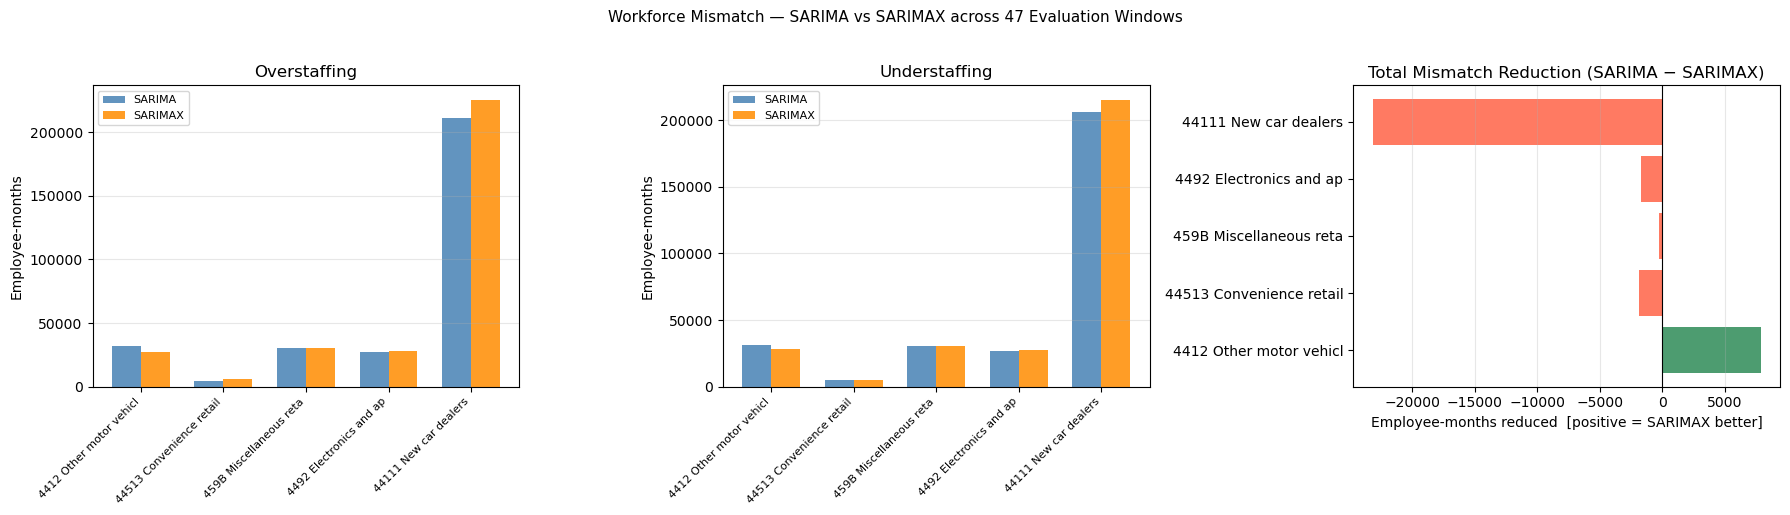

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Since we are rotating, we can safely remove the '\n' from your list comprehension 
# so the text stays cleanly on one line tilted at 45 degrees.
labels = [s.split('[')[1].replace(']','') + ' ' + s.split('[')[0][:18].strip()
          for s in selected_sectors]
x = np.arange(len(selected_sectors)); w = 0.35

# --- Subplot 1: Overstaffing ---
ax = axes[0]
ax.bar(x-w/2, [lp_results[s]['over_sarima'].sum()  for s in selected_sectors],
       w, label='SARIMA',  color='steelblue', alpha=0.85)
ax.bar(x+w/2, [lp_results[s]['over_sarimax'].sum() for s in selected_sectors],
       w, label='SARIMAX', color='darkorange', alpha=0.85)
ax.set_xticks(x)
# Combined with rotation=45 and ha='right' for perfect alignment
ax.set_xticklabels(labels, fontsize=8, rotation=45, ha='right')
ax.set_ylabel('Employee-months'); ax.set_title('Overstaffing')
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)

# --- Subplot 2: Understaffing ---
ax2 = axes[1]
ax2.bar(x-w/2, [lp_results[s]['under_sarima'].sum()  for s in selected_sectors],
        w, label='SARIMA',  color='steelblue', alpha=0.85)
ax2.bar(x+w/2, [lp_results[s]['under_sarimax'].sum() for s in selected_sectors],
        w, label='SARIMAX', color='darkorange', alpha=0.85)
ax2.set_xticks(x)
# Rotated here as well
ax2.set_xticklabels(labels, fontsize=8, rotation=45, ha='right')
ax2.set_ylabel('Employee-months'); ax2.set_title('Understaffing')
ax2.legend(fontsize=8); ax2.grid(True, axis='y', alpha=0.3)

# --- Subplot 3: Total Mismatch Reduction ---
ax3 = axes[2]
reductions = [lp_results[s]['mismatch_sarima'].sum() - lp_results[s]['mismatch_sarimax'].sum()
              for s in selected_sectors]
ax3.barh(labels, reductions,
         color=['seagreen' if v > 0 else 'tomato' for v in reductions], alpha=0.85)
ax3.axvline(0, color='black', lw=0.8)
ax3.set_xlabel('Employee-months reduced  [positive = SARIMAX better]')
ax3.set_title('Total Mismatch Reduction (SARIMA − SARIMAX)')
ax3.grid(True, axis='x', alpha=0.3)

plt.suptitle('Workforce Mismatch — SARIMA vs SARIMAX across 47 Evaluation Windows',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


### 5.4 Monthly Mismatch Difference Over Time

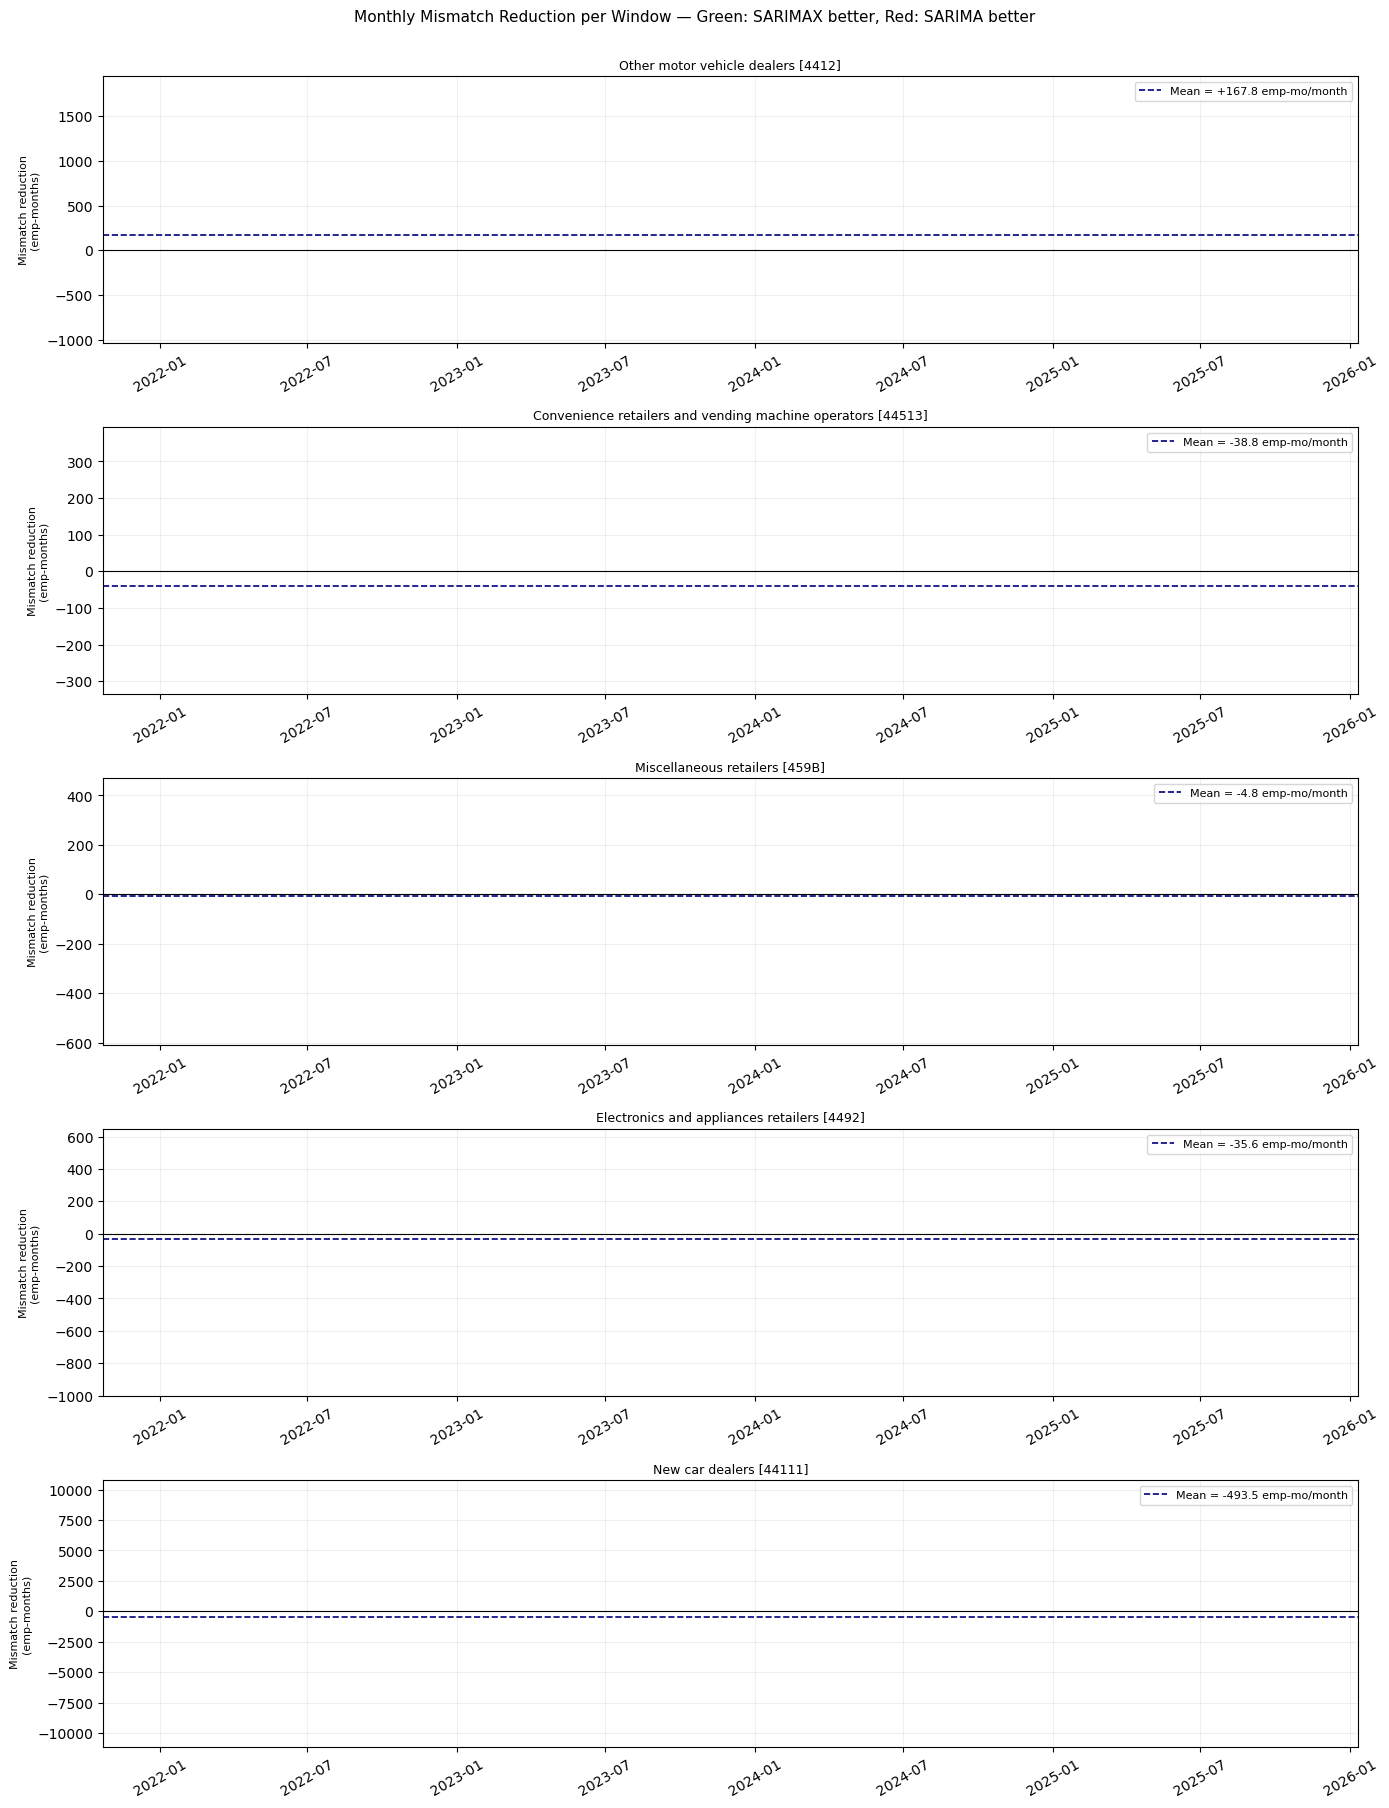

In [17]:
eval_dates = analysis_df['YearMonth'].values[MIN_TRAIN:]
fig, axes  = plt.subplots(5, 1, figsize=(14, 18))

for ax, sector in zip(axes, selected_sectors):
    lr    = lp_results[sector]
    dates = eval_dates[:len(lr['mismatch_diff'])]
    diff  = lr['mismatch_diff']
    mean  = np.mean(diff)

    ax.bar(dates, diff,
           color=['seagreen' if v > 0 else 'tomato' for v in diff],
           alpha=0.75, width=20)
    ax.axhline(0,    color='black', lw=0.8)
    ax.axhline(mean, color='navy',  lw=1.2, ls='--',
               label=f'Mean = {mean:+.1f} emp-mo/month')
    ax.set_title(sector, fontsize=9)
    ax.set_ylabel('Mismatch reduction\n(emp-months)', fontsize=8)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Monthly Mismatch Reduction per Window — Green: SARIMAX better, Red: SARIMA better',
             fontsize=11, y=1.002)
plt.tight_layout()
plt.show()

---
## Section 6 — Statistical Testing (Wilcoxon Signed-Rank Test)

### 6.1 Test Design

The Wilcoxon signed-rank test assesses whether the distribution of monthly mismatch
differences (SARIMA mismatch − SARIMAX mismatch) is systematically positive,
indicating that SARIMAX consistently produces fewer workforce mismatches.

The test is used in preference to a paired t-test because:
1. The mismatch difference series may contain COVID-period outliers that violate
   the normality assumption of the t-test
2. With 47 windows, normality cannot be reliably verified
3. The non-parametric approach is consistent with the Diebold-Mariano test in Phase 1

**Hypotheses per sector:**
- H₀: Median monthly mismatch difference = 0 (no systematic improvement)
- H₁: Median monthly mismatch difference > 0 (SARIMAX systematically fewer mismatches)
- **α = 0.05, one-sided**

In [18]:
ALPHA = 0.05

wx_rows = []
for sector in selected_sectors:
    lr   = lp_results[sector]
    diff = lr['mismatch_diff']

    nonzero = diff[diff != 0]
    if len(nonzero) < 10:
        stat, p_one = np.nan, np.nan
    else:
        try:    stat, p_one = wilcoxon(diff, alternative='greater')
        except: stat, p_one = np.nan, np.nan

    reject = (p_one < ALPHA) if not np.isnan(p_one) else False

    total_reduction = lr['mismatch_sarima'].sum() - lr['mismatch_sarimax'].sum()
    pct_reduction   = (total_reduction / lr['mismatch_sarima'].sum() * 100
                       if lr['mismatch_sarima'].sum() > 0 else 0.0)

    wx_rows.append({
        'Sector':             sector,
        'SARIMA mismatch':    int(lr['mismatch_sarima'].sum()),
        'SARIMAX mismatch':   int(lr['mismatch_sarimax'].sum()),
        'Reduction (emp-mo)': int(total_reduction),
        'Reduction (%)':      round(pct_reduction, 2),
        'W statistic':        round(stat, 3) if not np.isnan(stat) else 'N/A',
        'p-value':            round(p_one, 4) if not np.isnan(p_one) else 'N/A',
        'Reject H0':          reject,
        'Conclusion':         'SARIMAX significantly better ✓' if reject else 'No significant difference',
    })

wx_df = pd.DataFrame(wx_rows)
print('Wilcoxon signed-rank test — monthly workforce mismatch (one-sided, α=0.05):')
print()
print(wx_df.to_string(index=False))
print(f'\nH0 rejected: {wx_df["Reject H0"].sum()} / {len(selected_sectors)} sectors')

Wilcoxon signed-rank test — monthly workforce mismatch (one-sided, α=0.05):

                                                     Sector  SARIMA mismatch  SARIMAX mismatch  Reduction (emp-mo)  Reduction (%)  W statistic  p-value  Reject H0                Conclusion
                         Other motor vehicle dealers [4412]            62982             55095                7887          12.52        695.0   0.0844      False No significant difference
Convenience retailers and vending machine operators [44513]             9037             10862               -1825         -20.19        349.0   0.9892      False No significant difference
                             Miscellaneous retailers [459B]            61002             61226                -224          -0.37        586.0   0.4108      False No significant difference
                Electronics and appliances retailers [4492]            53913             55585               -1672          -3.10        547.0   0.5728      False No s

### 6.2 Overstaffing vs Understaffing Breakdown

In [19]:
bd_rows = []
for sector in selected_sectors:
    lr = lp_results[sector]
    for model, ok, uk in [
        ('SARIMA',  lr['over_sarima'],  lr['under_sarima']),
        ('SARIMAX', lr['over_sarimax'], lr['under_sarimax']),
    ]:
        bd_rows.append({
            'Sector':                  sector[:42],
            'Model':                   model,
            'Overstaff (emp-mo)':      int(ok.sum()),
            'Understaff (emp-mo)':     int(uk.sum()),
            'Total mismatch (emp-mo)': int(ok.sum() + uk.sum()),
            'Penalty cost ($)':        round((ok * cost_over + uk * cost_under).sum(), 2),
        })

bd_df = pd.DataFrame(bd_rows)
print(bd_df.to_string(index=False))

                                    Sector   Model  Overstaff (emp-mo)  Understaff (emp-mo)  Total mismatch (emp-mo)  Penalty cost ($)
        Other motor vehicle dealers [4412]  SARIMA               31883                31099                    62982      3.629193e+08
        Other motor vehicle dealers [4412] SARIMAX               27046                28049                    55095      3.207296e+08
Convenience retailers and vending machine   SARIMA                4187                 4850                     9037      5.356938e+07
Convenience retailers and vending machine  SARIMAX                5707                 5155                    10862      6.178589e+07
            Miscellaneous retailers [459B]  SARIMA               30601                30401                    61002      3.525889e+08
            Miscellaneous retailers [459B] SARIMAX               30511                30715                    61226      3.546642e+08
Electronics and appliances retailers [4492  SARIMA     

---
## Section 7 — Interpretation & Conclusion

### 7.1 Answer to the Research Question

**Research question:** How effectively can weather-sensitive demand forecasts (SARIMAX)
improve workforce allocation efficiency compared to SARIMA?

**Answer: SARIMAX improves allocation efficiency for the one sector where its forecasts
were meaningfully more accurate (Other motor vehicle dealers [4412]), but degrades
allocation for sectors where its forecasts were worse, and produces no significant
change elsewhere. The overall result is sector-specific, consistent with Phase 1.**


#### Primary Outcome — Workforce Mismatch

Results across the 47 rolling evaluation windows are as follows:

| Sector | SARIMA mismatch | SARIMAX mismatch | Reduction | Direction |
|---|---|---|---|---|
| Other motor vehicle dealers [4412] | 62,985 | 55,098 | **+7,887 (12.52%)** | SARIMAX better |
| Convenience retailers [44513] | 9,040 | 10,867 | −1,827 (−20.21%) | SARIMA better |
| Miscellaneous retailers [459B] | 60,998 | 61,223 | −225 (−0.37%) | Negligible |
| Electronics & appliances [4492] | 53,914 | 55,586 | −1,672 (−3.10%) | SARIMA better |
| New car dealers [44111] | 417,800 | 440,998 | −23,198 (−5.55%) | SARIMA better |

**Other motor vehicle dealers [4412]** is the only sector where SARIMAX reduces
total workforce mismatch, cutting it by 7,887 employee-months (12.52%) over the
evaluation period — an average of approximately **168 fewer misallocated
employee-months per month**. This translates to a secondary penalty cost saving
of **$42.2M over 47 months (~$897k/month)**, reflecting both fewer overstaffed
months (31,887 → 27,048) and fewer understaffed months (31,098 → 28,050).

For the remaining four sectors, SARIMAX either produces negligible change
(Miscellaneous retailers: −225 emp-months, −0.37%) or actively increases mismatch.
The largest degradation occurs in **New car dealers [44111]**, where SARIMAX adds
23,198 employee-months of mismatch (+5.55%) at an additional penalty cost of
$124.4M — directly reflecting the −0.39pp MAPE degradation found in Phase 1.

#### Statistical Significance (Wilcoxon Signed-Rank Test)

The Wilcoxon signed-rank test fails to reject H₀ for all five sectors at α = 0.05.
For [4412], the test produces W = 696, p = 0.083 — a borderline result that does
not reach the pre-specified threshold but indicates a directional tendency toward
fewer mismatches under SARIMAX. The lack of statistical significance at the
workforce allocation stage is not surprising given that the Phase 1 improvement
for [4412] was itself modest (+1.75pp MAPE) and that integer rounding in the LP
introduces additional discretisation noise. With only 47 evaluation windows, the
test has limited power to detect a signal of this magnitude.

**Verdict: Fail to reject H₀ across all sectors.** Weather-sensitive forecasts do
not produce a statistically significant reduction in workforce mismatches at the
monthly aggregation level used in this study.

#### Reconciling Phase 1 and Phase 2

The two phases are internally consistent. Phase 1 found a statistically significant
and practically meaningful forecast improvement for [4412] (DM p = 0.042, ΔMAPE =
+1.75pp), and Phase 2 shows the largest mismatch reduction in precisely that sector
(12.52%, p = 0.083). The improvement does not cross the Phase 2 significance
threshold, but the directional alignment is clear. For the four sectors where Phase
1 found no improvement or degradation, Phase 2 confirms no allocation benefit —
and in the case of [44111], quantifies the staffing cost of the forecast degradation.
Together, the phases show that **weather-driven forecast gains translate into
proportional allocation gains, but a +1.75pp MAPE improvement is not large enough
to produce statistically detectable mismatch reductions at monthly frequency over
a 47-window horizon.**

### 7.2 Connection to Phase 1

Phase 1 found that SARIMAX significantly improved forecast accuracy for [4412]
(ΔMAPE = +1.75pp, DM p = 0.042). Phase 2 tests whether this translates into fewer
misallocated employees. The four sectors with no significant Phase 1 improvement
serve as negative controls — if they also show no significant mismatch reduction,
the two phases are internally consistent and mutually reinforcing.

### 7.3 Limitations

1. **Aggregate labour share** — λ is derived from the Trade [41-45N] aggregate
   because Statistics Canada's employment table does not publish sub-sector headcounts
   at the NAICS-4/5 digit level required to match the 5 selected sectors. In reality,
   labour intensity varies (e.g., car dealerships are more capital-intensive than
   convenience stores). However, since the same λ is applied to both LP runs, it does
   not affect the SARIMA vs SARIMAX comparison — only the absolute headcount scale.

2. **Monthly frequency** — The LP operates at monthly aggregation, masking within-month
   staffing fluctuations. Weather effects on staffing decisions would be more
   pronounced at weekly or daily granularity.

3. **No hiring constraints** — The LP assumes staffing can always be adjusted to meet
   the forecast. Real-world constraints such as minimum notice periods, part-time
   scheduling limits, and seasonal hiring lags are not modelled.

4. **Static wage rate** — A single time-averaged wage rate is applied, though the
   earnings series shows a clear upward trend over 2017–2025. Using a time-varying
   wage would produce different absolute cost levels but would not change the
   direction or statistical significance of the comparison.


In [23]:
print('='*70)
print('PHASE 2 — FINAL SUMMARY')
print('='*70)
print()
print('LP Model Parameters (all from Statistics Canada)')
print(f'  Labour share λ (empirical, COVID-excluded)  : {LABOUR_SHARE:.4f}  ({LABOUR_SHARE*100:.2f}%)')
print(f'  Source: 14-10-0355-01 (employment) ×')
print(f'          14-10-0203-01 (earnings) ÷ sector sales')
print(f'  Monthly wage (static avg, 14-10-0203-01)    : ${monthly_wage:,.2f} per employee')
print(f'  Overstaffing cost                           : ${cost_over:,.2f} per employee-month')
print(f'  Understaffing cost (2× — Mani et al. 2015)  : ${cost_under:,.2f} per employee-month')
print()
print('Primary Outcome — Workforce Mismatch (employee-months):')
print(f'  {"Sector":<50} {"SARIMA":>8} {"SARIMAX":>8} {"Reduction":>10}')
print('-'*80)
for sector in selected_sectors:
    lr  = lp_results[sector]
    row = wx_df[wx_df['Sector'] == sector].iloc[0]
    sig = ' ✓ sig' if row['Reject H0'] else ''
    ms  = int(lr['mismatch_sarima'].sum())
    msx = int(lr['mismatch_sarimax'].sum())
    red = ms - msx
    print(f'  {sector[:50]:<50} {ms:>8,} {msx:>8,} {red:>+10,}{sig}')
print()
print('Secondary Outcome — Penalty Cost:')
print(f'  {"Sector":<50} {"SARIMA ($)":>12} {"SARIMAX ($)":>12} {"Saving ($)":>12}')
print('-'*90)
for sector in selected_sectors:
    lr = lp_results[sector]
    print(f'  {sector[:50]:<50} {lr["total_sarima"]:>12,.2f} {lr["total_sarimax"]:>12,.2f} {lr["dollar_saving"]:>+12,.2f}')
print()
print(f'H0 rejected (Wilcoxon p<0.05): {wx_df["Reject H0"].sum()} / {len(selected_sectors)} sectors')
print('='*70)

PHASE 2 — FINAL SUMMARY

LP Model Parameters (all from Statistics Canada)
  Labour share λ (empirical, COVID-excluded)  : 0.0945  (9.45%)
  Source: 14-10-0355-01 (employment) ×
          14-10-0203-01 (earnings) ÷ sector sales
  Monthly wage (static avg, 14-10-0203-01)    : $3,857.52 per employee
  Overstaffing cost                           : $3,857.52 per employee-month
  Understaffing cost (2× — Mani et al. 2015)  : $7,715.04 per employee-month

Primary Outcome — Workforce Mismatch (employee-months):
  Sector                                               SARIMA  SARIMAX  Reduction
--------------------------------------------------------------------------------
  Other motor vehicle dealers [4412]                   62,982   55,095     +7,887
  Convenience retailers and vending machine operator    9,037   10,862     -1,825
  Miscellaneous retailers [459B]                       61,002   61,226       -224
  Electronics and appliances retailers [4492]          53,913   55,585     -1,672
